In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_5K_pbmc_rnaseq',
    zarr=True,
    destination='scarf_datasets'
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/dendrogram//data: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

...

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

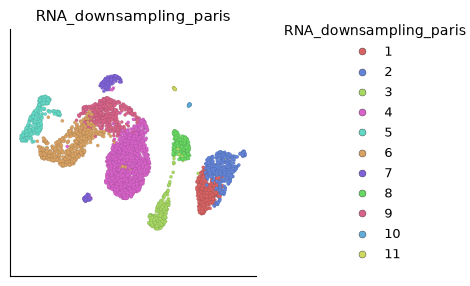

In [3]:
analysis_directory = TemporaryDirectory()
repacked_counts_path = Path(analysis_directory.name) / 'counts.zarr'
analysis_path = Path(analysis_directory.name) / 'downsampling.zarr'
repack_store(
    f'{dataset}/data.zarr',
    str(repacked_counts_path),
    nthreads=2,
)
ds = scarf.mount_datastore(
    str(repacked_counts_path),
    at=str(analysis_path),
    default_assay='RNA',
    nthreads=4,
)

hvg_ref = ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
normalized = ds.run_normalization(features=hvg_ref)
pca = ds.run_pca(normalized, dims=15)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=11)
graph = ds.build_connectivity_map(neighbors)
paris = ds.run_paris_clustering(
    graph=graph,
    label='downsampling_paris',
)
paris_key = paris.label_key

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris_key,
)

In [4]:
ds.run_topacedo_sampler(
    graph=graph,
    cluster_key=paris_key,
    max_sampling_rate=0.1
)
if 'RNA_sketched' not in ds.cells.columns:
    raise RuntimeError(
        "TopACeDo did not create RNA_sketched. Verify that topacedo is installed."
    )

{
    'active cells': int(ds.cells.fetch_all('I').sum()),
    'seed cells': int(ds.cells.fetch_all('RNA_sketch_seeds').sum()),
    'selected cells': int(ds.cells.fetch_all('RNA_sketched').sum()),
}

INFO: 341 cells (8.65%) sub-sampled. Subsample to Seed (148 cells) ratio: 2.304


Constructing graph from dendrogram: 3939 / 3939 complete

{'active cells': 3940, 'seed cells': 148, 'selected cells': 341}

In [5]:
sampling = ds.cells.to_pandas_dataframe(
    columns=[paris_key, 'RNA_sketched', 'RNA_sketch_seeds'],
    key='I',
)
cluster_sampling = sampling.groupby(paris_key, sort=True).agg(
    cells=(paris_key, 'size'),
    seeds=('RNA_sketch_seeds', 'sum'),
    selected=('RNA_sketched', 'sum'),
)
cluster_sampling['sampling_rate'] = (
    cluster_sampling['selected'] / cluster_sampling['cells']
).round(3)
cluster_sampling

,cells,seeds,selected,sampling_rate
RNA_downsampling_paris,,,,
1,337,11,27,0.080
2,385,18,39,0.101
3,257,9,21,0.082
4,1269,25,71,0.056
5,317,21,52,0.164
6,558,27,54,0.097
7,137,7,12,0.088
8,243,7,16,0.066
9,410,17,42,0.102


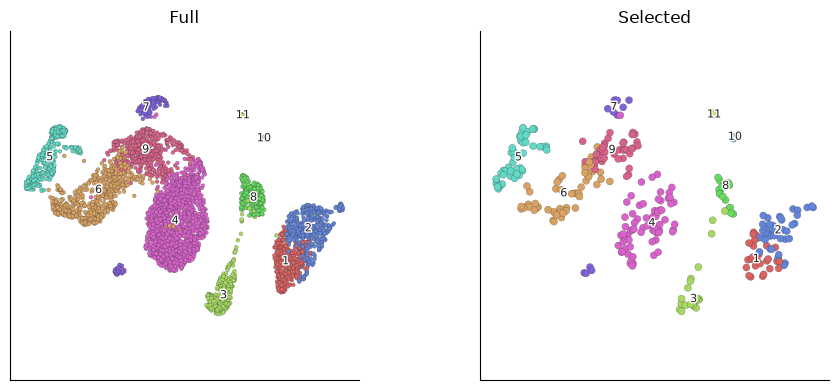

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris_key,
    legend_loc='on_data',
    show_titles=False,
    target=axes[0],
    show=False,
)
axes[0].set_title('Full')
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris_key,
    subset_by='RNA_sketched',
    legend_loc='on_data',
    show_titles=False,
    target=axes[1],
    show=False,
)
axes[1].set_title('Selected')
figure.tight_layout()
figure

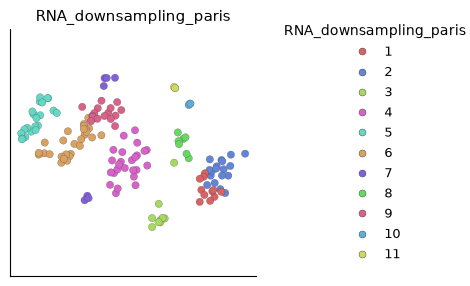

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris_key,
    subset_by='RNA_sketch_seeds',
)

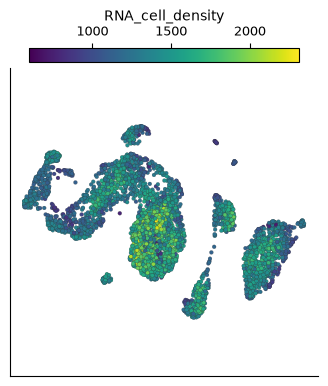

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density',
)

In [9]:
density = ds.cells.to_pandas_dataframe(
    columns=['RNA_cell_density', 'RNA_sketched'],
    key='I',
)
density['density_bin'] = pd.qcut(
    density['RNA_cell_density'],
    q=5,
    duplicates='drop',
)
(
    density.groupby('density_bin', observed=True)
    .agg(
        cells=('RNA_sketched', 'size'),
        selected=('RNA_sketched', 'sum'),
    )
    .assign(
        selection_rate=lambda frame: (
            frame['selected'] / frame['cells']
        ).round(3)
    )
)

,cells,selected,selection_rate
density_bin,,,
"(599.3100000000001, 1216.425]",788,73,0.093
"(1216.425, 1369.025]",788,65,0.082
"(1369.025, 1501.727]",788,76,0.096
"(1501.727, 1670.606]",788,69,0.088
"(1670.606, 2310.368]",788,58,0.074


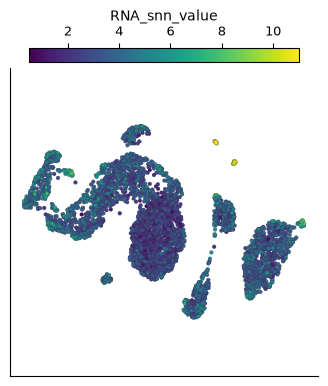

In [10]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value',
)

In [11]:
subset_path = Path(analysis_directory.name) / 'subset.zarr'
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

Subsetting assay: RNA: 1 / 1 complete

In [12]:
ds2 = scarf.DataStore(str(subset_path))
{
    "source cells": ds.cells.N,
    "subset cells": ds2.cells.N,
    "source RNA features": ds.RNA.feats.N,
    "subset RNA features": ds2.RNA.feats.N,
}

Computing RNA initialization statistics: 1 / 1 complete

{'source cells': 5025,
 'subset cells': 341,
 'source RNA features': 33538,
 'subset RNA features': 33538}

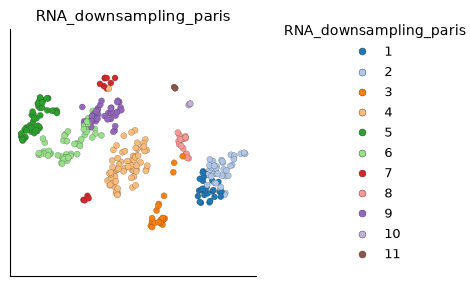

In [13]:
ds2.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris_key,
)

In [14]:
adata = ds2.to_anndata()
adata.shape

Converting RNA raw data to CSR: 1 / 1 complete

(341, 33538)